<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Image_preprocessing_IX.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Computer vision tasks**

## **Introduction to Face Detection**

This notebook explores various techniques for face detection using OpenCV's Haar Cascades. Face detection is a fundamental computer vision task that involves identifying the location and size of human faces in digital images or videos. It has numerous applications, including:

*   **Security:** Facial recognition systems, surveillance.
*   **Photography:** Automatic focus, red-eye reduction, photo organization.
*   **Entertainment:** Face filters, augmented reality.
*   **Human-Computer Interaction:** Gaze estimation, expression analysis.

In this notebook, we will cover:

1.  **Single Face Detection:** Basic detection on an image with one face.
2.  **Multiple Face Detection:** Detecting several faces in more complex scenarios, including adjusting parameters for optimal results.
3.  **Face Blurring:** Applying techniques to blur detected faces for privacy or artistic effects.

We will utilize the `haarcascade_frontalface_default.xml` classifier, a pre-trained model provided by OpenCV, and explore how to fine-tune its parameters for different image conditions.

## **Face detection - Single face**

In [1]:
# Importing libraries
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

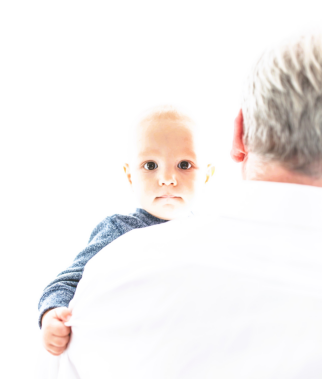

In [2]:
# Attaching the input image - Single face

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/baby_face.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

After the input image has been ready, we need to obtain the the Haar cascade XML file and place it on a directory.

In [3]:
# Downloading 'haarcascades'

import os

# Define the URL for the Haar Cascade XML file
haar_cascade_url = 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml'

# Define the directory and filename
cascade_dir = 'haarcascades'
cascade_filename = os.path.join(cascade_dir, 'haarcascade_frontalface_default.xml')

# Create the directory if it doesn't exist
if not os.path.exists(cascade_dir):
    os.makedirs(cascade_dir)

# Download the file
print(f'Downloading {haar_cascade_url} to {cascade_filename}...')
urllib.request.urlretrieve(haar_cascade_url, cascade_filename)
print('Download complete!')

Download complete!


In [4]:
# Preparing the Haar Cascade model
face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_default.xml')

Now, we need to apply the model by using detectMultiScale() function

In [5]:
# Applying face detection
face_detection = face_cascade.detectMultiScale(input_img)

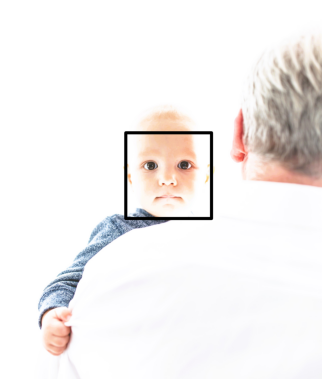

In [6]:
# Draw rectangles around the detected face
output_img = input_img.copy()
for (x, y, w, h) in face_detection:
    cv2.rectangle(output_img,
                  (x, y),
                  (x+w, y+h),
                  (0, 0, 0),
                  30)

# Display the image with detected faces
plt.axis('off')
plt.imshow(output_img, cmap='gray')
plt.show()

## **Face detection - Multiple faces**

Now, let's improve the complexity of the detection process. We will use an image with multiple faces (also multi poses), smaller face size, and with different brightness.

The Haar Cascade algorithm can be powerful tools with correct adjustment as it may able to detect faces in this complex situation. However, the results are being influenced with many factors, such as the quality of classifier model, face size, and the level of brightness. Because of that, the adjustment of parameters is required to obtain optimum result.

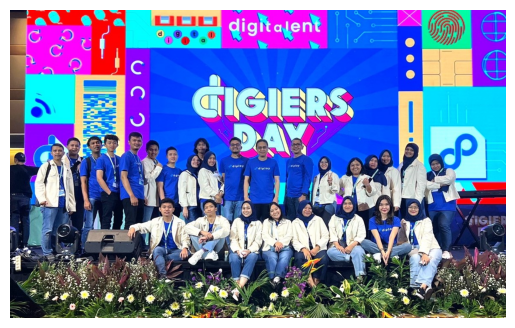

In [7]:
# Attaching the input image - multiple faces

# Image link
url_multiple_faces = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/faces_digiers.jpeg?raw=true'

# Download and open the image
with urllib.request.urlopen(url_multiple_faces) as f:
    multi_faces_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
multi_faces_img = np.array(multi_faces_img)

# Displaying the original image
plt.axis('off')
plt.imshow(multi_faces_img, cmap='gray')
plt.show()

We will use the previous downloaded haar cascade file

In [8]:
# Preparing the Haar Cascade model
face_cascade = cv2.CascadeClassifier('haarcascades/haarcascade_frontalface_default.xml')

In [15]:
# Applying face detection to the image
face_detection_2 = face_cascade.detectMultiScale(multi_faces_img,
                                                 minNeighbors=8,
                                                 scaleFactor=1.15,
                                                 maxSize=(40,40))


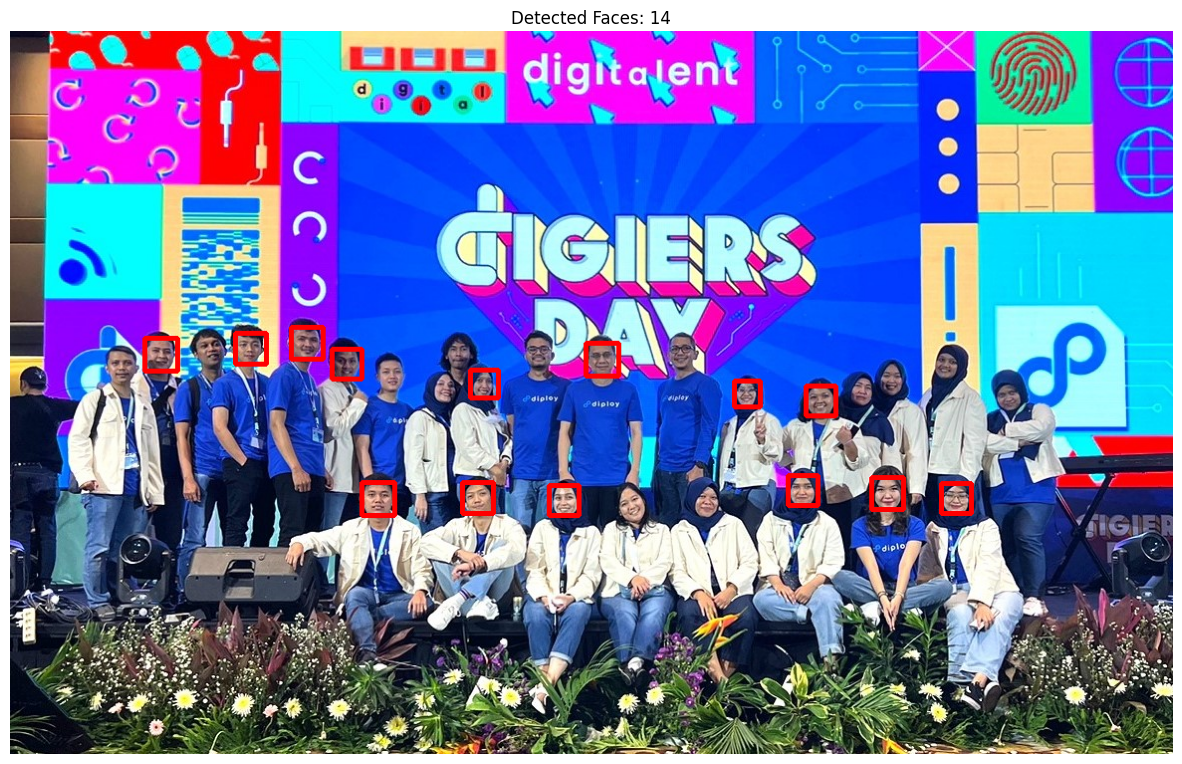

In [18]:
# Draw rectangles around the detected faces
output_multifaces = multi_faces_img.copy()

for(x, y, w, h) in face_detection_2:
        cv2.rectangle(output_multifaces, (x,y), (x+w, y+h), (255), 3)

plt.figure(figsize=(15,10))
plt.imshow(output_multifaces, cmap='gray')
plt.axis('off')
plt.title(f"Detected Faces: {len(face_detection_2)}")
plt.show()

We have detected 14 faces. We need to provide more adjustment to the parameters.

The parameters for the face detection algorithm (Haarcascade) consisting of,


1. `scaleFactor`
* What it does: Specifies how much the image size is reduced at each image scale.
* Why it matters: Faces closer to the camera are larger, while those far away are smaller. The detector creates a "scale pyramid" to detect faces of different sizes.
* Typical Value: 1.1 (reduces image by 10% per level). A higher value (e.g., 1.4) makes detection faster but might miss faces. A smaller value makes detection slower but more thorough.

2. `minNeighbors`
* What it does: Defines how many neighboring candidate rectangles must exist around a region for it to be declared a face.
* Why it matters: Controls the quality of the detection. The classifier detects multiple possible windows around a face; this filters them.
* Typical Value: 3 to 6. Higher values result in fewer detections but with higher quality (fewer false positives). Low values might pick up background noise as a face.

3. `minSize`
* What it does: Specifies the smallest possible size (in pixels) of the face to be detected, such as (30, 30).
* Why it matters: Ignores objects smaller than this size to speed up detection and reduce false positives.

4. `maxSize`
* What it does: Specifies the maximum possible size (in pixels) of the face to be detected.
* Why it matters: Ignores objects larger than this size. Usually, this is not set (default), meaning there is no upper limit on the size of the face.

In [19]:
# Upgrading parameters
# Adjusting minSize to a smaller value and minNeighbors for better detection
face_detection_3 = face_cascade.detectMultiScale(multi_faces_img,
                                                 minNeighbors=5,    # Reduced min neighbors
                                                 scaleFactor=1.03,  # Adjusting scale factor
                                                 minSize=(26,26),   # Setting minimun size
                                                 maxSize=(40,40))   # Setting maximum size

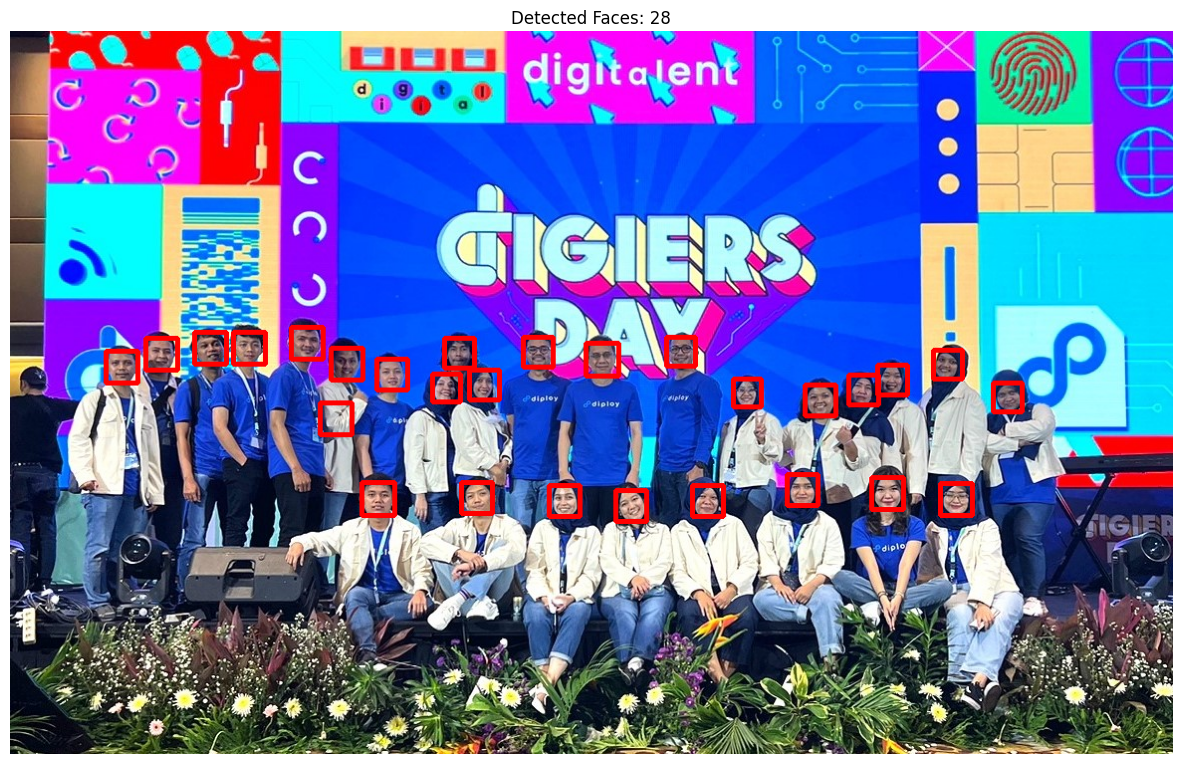

In [21]:
# Draw rectangles around the detected faces
output_multifaces_2 = multi_faces_img.copy()

for(x, y, w, h) in face_detection_3:
        cv2.rectangle(output_multifaces_2, (x,y), (x+w, y+h), (255), 3)

plt.figure(figsize=(15,10))
plt.imshow(output_multifaces_2, cmap='gray')
plt.axis('off')
plt.title(f"Detected Faces: {len(face_detection_3)}")
plt.show()

We have detected 28 faces, although there are only 27 faces. So, there is one false positive (detected as face, although there is none).

Now, lets apply more techniques by applying more filter.

In [22]:
# Defining non max suppression filter
def non_max_suppression(boxes, overlapThresh=0.3):
    if len(boxes) == 0:
        return []

    boxes = np.array(boxes)
    pick = []

    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,0] + boxes[:,2]
    y2 = boxes[:,1] + boxes[:,3]

    area = (x2 - x1) * (y2 - y1)
    idxs = np.argsort(y2)

    while len(idxs) > 0:
        last = idxs[-1]
        pick.append(last)

        xx1 = np.maximum(x1[last], x1[idxs[:-1]])
        yy1 = np.maximum(y1[last], y1[idxs[:-1]])
        xx2 = np.minimum(x2[last], x2[idxs[:-1]])
        yy2 = np.minimum(y2[last], y2[idxs[:-1]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        overlap = (w * h) / area[idxs[:-1]]
        idxs = idxs[np.where(overlap <= overlapThresh)[0]]

    return boxes[pick].astype(int)

In [23]:
# Adjusting parameters and applying filter

# Adjusting parameters
face_detection_4 = face_cascade.detectMultiScale(
    multi_faces_img,
    scaleFactor=1.03,
    minNeighbors=5,
    minSize=(26,26),
    maxSize=(40,40))

# Step 1: aspect ratio filter
filtered_faces = [(x,y,w,h) for (x,y,w,h) in face_detection_4 if 0.75 < w/h < 1.3]

# Step 2: spatial filter
H, W = multi_faces_img.shape[:2]
filtered_faces = [(x,y,w,h) for (x,y,w,h) in filtered_faces if y > H * 0.25]

# Step 3: NMS
final_faces = non_max_suppression(filtered_faces)

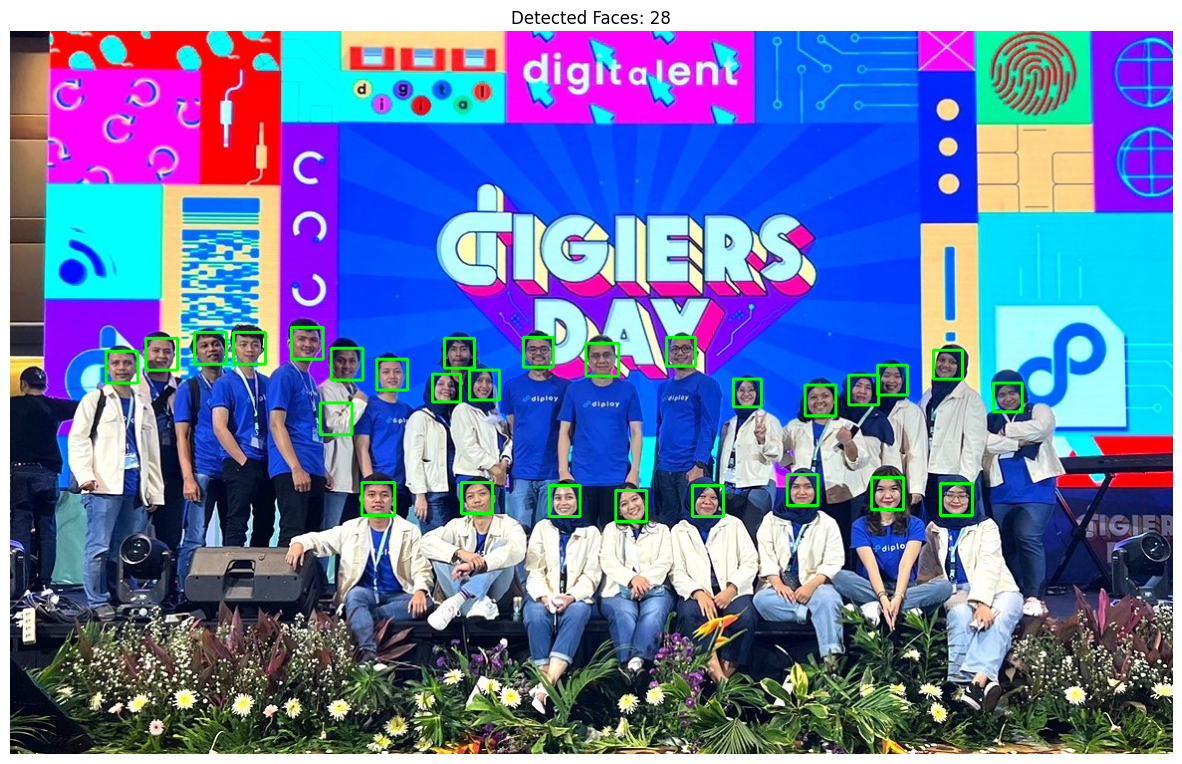

In [24]:
# Adding bounding boxes and displaying the result
output_multifaces_3 = multi_faces_img.copy()

for (x, y, w, h) in final_faces:
    cv2.rectangle(output_multifaces_3, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.figure(figsize=(15,10))
plt.imshow(output_multifaces_3, cmap='gray')
plt.axis('off')
plt.title(f"Detected Faces: {len(final_faces)}")
plt.show()

Although we have applied more filters, we still have one false positive. We may improve this accuracy, but there are more adjustments to do that.

## **Face detection - multiple and blurred faces**

We can also detect multiple faces and perform blurring to the faces.

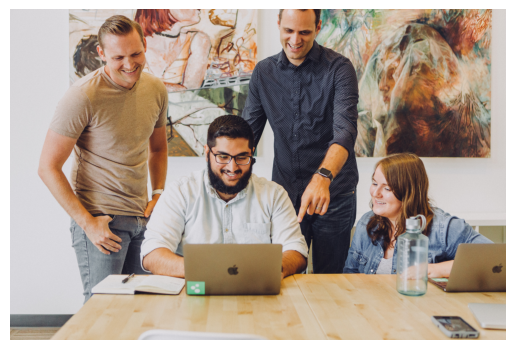

In [26]:
# Attaching the input image - multiple & blurred faces

# Image link
url_blurred_faces = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/many_faces.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url_blurred_faces) as f:
    multi_faces_img_2 = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
multi_faces_img_2 = np.array(multi_faces_img_2)

# Displaying the original image
plt.axis('off')
plt.imshow(multi_faces_img_2, cmap='gray')
plt.show()

We will detect faces by adjusting parameters for multiple face detection. After that, we will extracting the region of interest that contain the face and applying gaussian blur to the region.

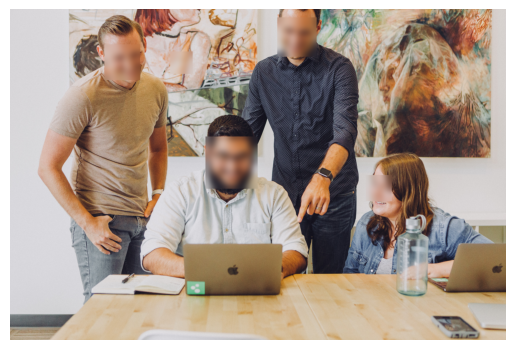

In [47]:
# Blurring

# Adjusting parameters for multiple face detection
face_detection_6 = face_cascade.detectMultiScale(multi_faces_img_2,
                                                 minNeighbors=4,   # Reduced min neighbors
                                                 scaleFactor=1.04, # Adjusting scale factor
                                                 minSize=(251,252))

# Drawing rectangles around the detected faces
output_multifaces_6 = multi_faces_img_2.copy()

# Extracting interest region and applying blur
for (x, y, w, h) in face_detection_6:
    target = output_multifaces_6[y:y+h, x:x+w]  # Extract the region of interest (ROI) containing the face
    blur = cv2.GaussianBlur(target, (251, 251), 0)  # Apply Gaussian blur to the ROI
    output_multifaces_6[y:y+h, x:x+w] = blur  # Replace the original face region with the blurred one

plt.axis('off')
plt.imshow(output_multifaces_6, cmap='gray')
plt.show()

We can see from the image above, the regions of interest (containing faces) have been blurred.

## **Conclusion**

In this notebook, we've explored the fundamentals of face detection using OpenCV's Haar Cascades. We started with basic single-face detection and then progressed to more complex scenarios involving multiple faces and parameter tuning.

Key takeaways include:

*   **Haar Cascades for Face Detection:** We successfully utilized the `haarcascade_frontalface_default.xml` classifier to detect faces in images.
*   **Parameter Tuning:** The `detectMultiScale` function's parameters, such as `scaleFactor`, `minNeighbors`, `minSize`, and `maxSize`, are crucial for optimizing detection accuracy, especially in images with varying face sizes, distances, and orientations.
*   **Filtering Techniques:** We demonstrated how to improve detection results by applying additional filters like aspect ratio and spatial filters, along with Non-Maximum Suppression (NMS), to reduce false positives.
*   **Practical Application (Face Blurring):** We applied face detection to a practical scenario by blurring detected faces for privacy, showcasing how to manipulate regions of interest based on detection results.

While Haar Cascades are effective, they can sometimes be sensitive to lighting, pose variations, and occlusion. Modern face detection techniques often involve deep learning models (e.g., MTCNN, YOLO, SSD) that offer higher accuracy and robustness. However, Haar Cascades remain a valuable and computationally efficient method for many applications, especially where simplicity and speed are prioritized.